In [1]:
from google.colab import userdata
from huggingface_hub import login

In [2]:
login(token=userdata.get('niru_hf_read'))

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B")

In [4]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

In [ ]:
# Input text
text = "BERT requires a mask input for masked positions"

# Tokenize input
inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Get attention scores
with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        return_dict=True
    )

In [6]:
outputs.logits.shape

torch.Size([1, 9, 128256])

In [7]:
# Get next token probabilities
next_token_probs = torch.softmax(outputs.logits[0, -1, :], dim=-1)

top_k = torch.topk(next_token_probs, k=7)

for prob, idx in zip(top_k.values, top_k.indices):
    token = tokenizer.decode(idx)
    print(f"Token: {token}, Probability: {prob:.3f}")

Token: ., Probability: 0.315
Token: ,, Probability: 0.176
Token: .
, Probability: 0.111
Token:  and, Probability: 0.074
Token:  to, Probability: 0.069
Token:  in, Probability: 0.042
Token:  (, Probability: 0.037


In [8]:
# Get attention from last layer and average across heads
attention_scores = outputs.attentions[-1].squeeze(0).mean(dim=0).numpy()

In [9]:
attention_scores.shape

(9, 9)

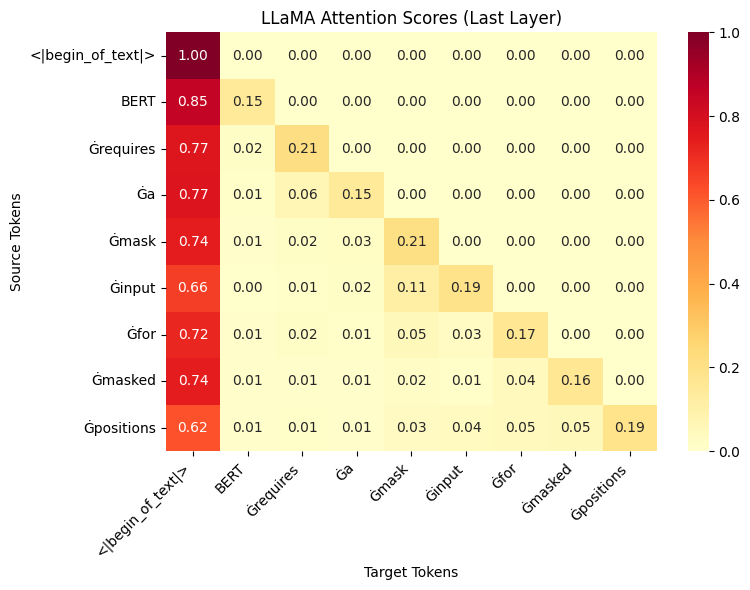


Top 3 tokens attended by 'Ġa':
<|begin_of_text|>: 0.7747
Ġa: 0.1479
Ġrequires: 0.0639


In [10]:
# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_scores,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="YlOrRd",
    annot=True,
    fmt='.2f'
)

# Customize plot
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Target Tokens')
plt.ylabel('Source Tokens')
plt.title('LLaMA Attention Scores (Last Layer)')
plt.tight_layout()

# Show plot
plt.show()

# Print top attention scores for a specific token (e.g., "fox")
token_position = 3  # Position of "fox" in the sequence
token_attention = attention_scores[token_position]
top_k = 3

print(f"\nTop {top_k} tokens attended by '{tokens[token_position]}':")
top_indices = token_attention.argsort()[-top_k:][::-1]
for idx in top_indices:
    print(f"{tokens[idx]}: {token_attention[idx]:.4f}")